# Stratified Sampling

Using custom drawn PNG masks, we separate each class, {water, soil, canopy, grass}, then builds the reusable ground-truth label map for entire region image.

In [27]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from PIL import Image
from scipy.ndimage import binary_dilation
from tqdm import tqdm

data_dir = Path("../data/SA1_K4")
HDR_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.hdr"
DAT_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.dat"

ZARR_PATH = data_dir / "SA1_K4_HS_MOZ.zarr"
ZARR_META_PATH = data_dir/ "SA1_K4_HS_MOZ.zarr_metadata.json"

RGB_PATH = "../masks/.rgb_reference.png"



# store colors for combined masks, visual only
class_mask_colors = [
    ("water", 1, np.array([0, 0, 255], dtype=np.uint8)),
    ("soil", 2, np.array([139, 69, 19], dtype=np.uint8)),
    ("canopy", 3, np.array([0, 80, 0], dtype=np.uint8)),
    ("grass", 4, np.array([144, 238, 144], dtype=np.uint8)),
]


def load_alpha_mask(path):
    img = np.array(Image.open(path))

    if img.ndim == 3 and img.shape[2] == 4:
        return img[:, :, 3] > 0

    raise ValueError(f"Expected RGBA transparent PNG mask, got shape={img.shape} for {path}")


hs_zarr = zarr.open(str(ZARR_PATH), mode="r")
class_stats = {}
wavelengths = None



Reference RGB

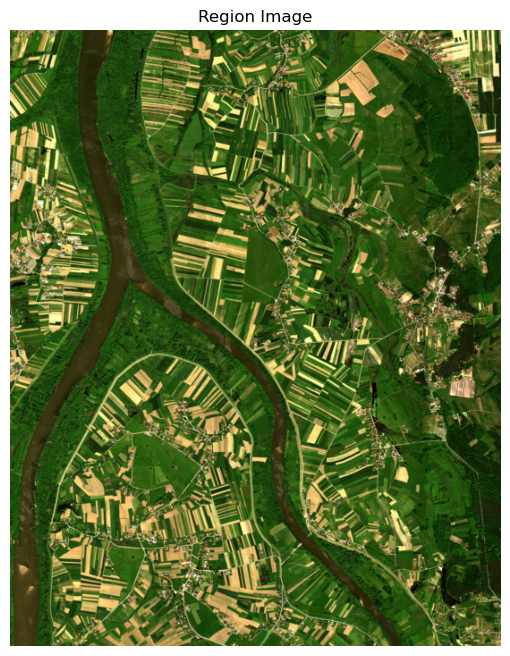

In [28]:
rgb = np.array(Image.open(RGB_PATH).convert("RGB"))

plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.title("Region Image")
plt.axis("off")
plt.show()


Combine the four binary masks into a single numeric label image and save it as numpy label masks for future 


Overlapping pixels: 2252
Saved: ../masks/class_mask.npy


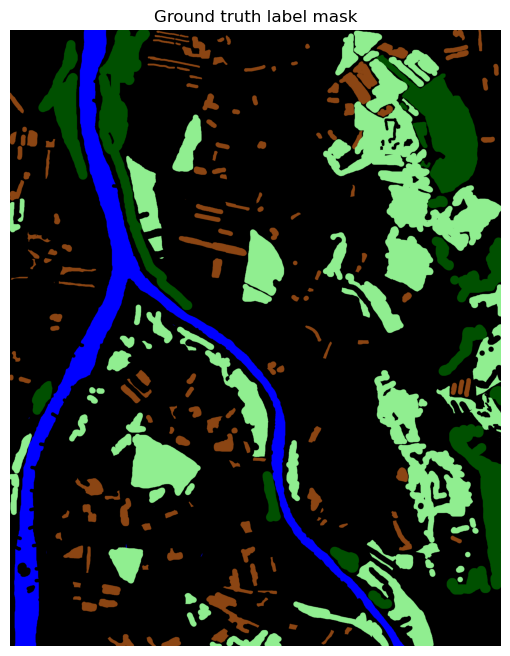

In [29]:
rows, cols, _ = hs_zarr.shape
label_mask = np.zeros((rows, cols), dtype=np.uint8)
overlap_count = np.zeros((rows, cols), dtype=np.uint8)

for class_name, class_id, _ in class_mask_colors:
    binary_mask = load_alpha_mask(MASK_DIR / f"{class_name}_mask.png")
    overlap_count += binary_mask.astype(np.uint8)
    label_mask[binary_mask] = class_id

print("Overlapping pixels:", int(np.count_nonzero(overlap_count > 1)))
np.save("../masks/class_mask.npy", label_mask)
print("Saved:", "../masks/class_mask.npy")

gt_rgb = np.zeros((rows, cols, 3), dtype=np.uint8)
for _, class_id, color in class_mask_colors:
    gt_rgb[label_mask == class_id] = color

plt.figure(figsize=(10, 8))
plt.imshow(gt_rgb)
plt.title("Ground truth label mask")
plt.axis("off")
plt.show()


Overlay visual Check

Resizing label mask to match RGB image for visualization only.


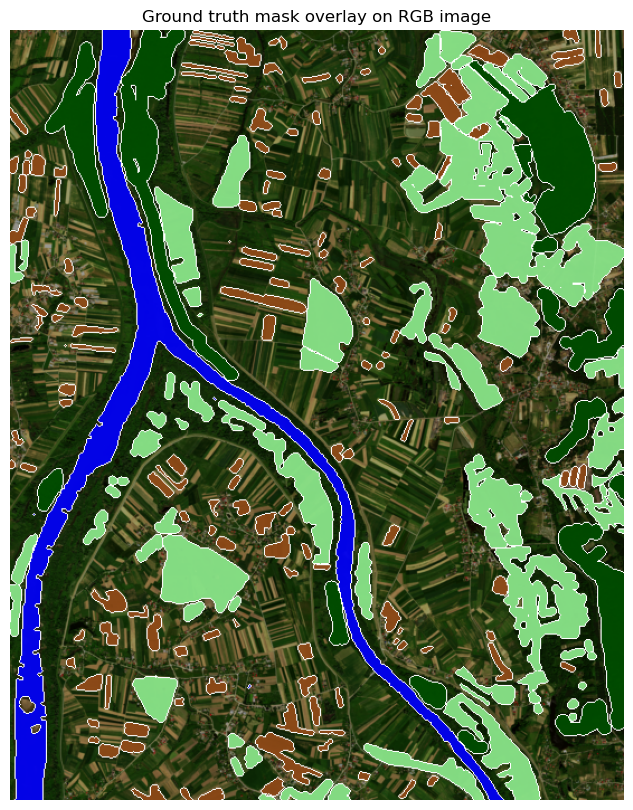

In [21]:
if label_mask.shape != rgb.shape[:2]:
    print("Resizing label mask to match RGB image for visualization only.")
    label_img = Image.fromarray(label_mask)
    label_img = label_img.resize((rgb.shape[1], rgb.shape[0]), resample=Image.NEAREST)
    label_vis = np.array(label_img)
else:
    label_vis = label_mask

mask_rgb = np.zeros_like(rgb, dtype=np.uint8)
for _, class_id, color in class_mask_colors:
    mask_rgb[label_vis == class_id] = color

rgb_dim = (rgb.astype(np.float32) * 0.6).astype(np.uint8)
alpha = np.zeros(label_vis.shape, dtype=np.float32)
alpha[label_vis > 0] = 0.90

overlay = (
    rgb_dim.astype(np.float32) * (1 - alpha[:, :, None]) +
    mask_rgb.astype(np.float32) * alpha[:, :, None]
).astype(np.uint8)

for _, class_id, _ in class_mask_colors:
    class_mask = label_vis == class_id
    edge = binary_dilation(class_mask, iterations=1) & ~class_mask
    overlay[edge] = np.array([255, 255, 255], dtype=np.uint8)

plt.figure(figsize=(12, 10))
plt.imshow(overlay)
plt.title("Ground truth mask overlay on RGB image")
plt.axis("off")
plt.show()


## Compute Class Spectra

Load the Zarr cube once, then reuse it for all four masks. Each class produces a mean spectrum and a standard-deviation envelope.

does not load the entire hyperspectral cube into RAM. It opens a handle to the Zarr dataset on disk.

Then inside the loop, this line reads only the needed band block:
So for each class, it reads the Zarr cube in spectral chunks, for example 16 bands at a time.


Computing water stats: 100%|██████████| 27/27 [00:58<00:00,  2.18s/band-block]
water: 1,889,413 pixels


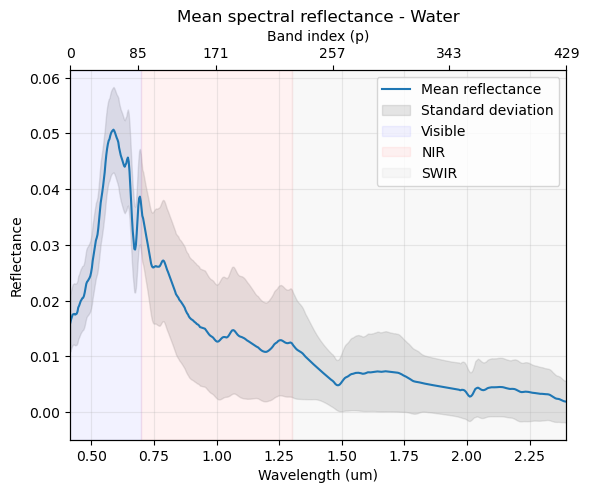

Computing soil stats: 100%|██████████| 27/27 [00:58<00:00,  2.17s/band-block]
soil: 1,578,685 pixels


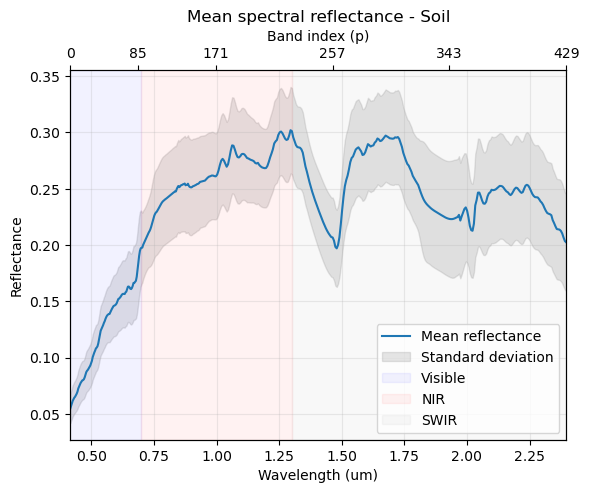

Computing canopy stats: 100%|██████████| 27/27 [00:59<00:00,  2.22s/band-block]
canopy: 2,598,161 pixels


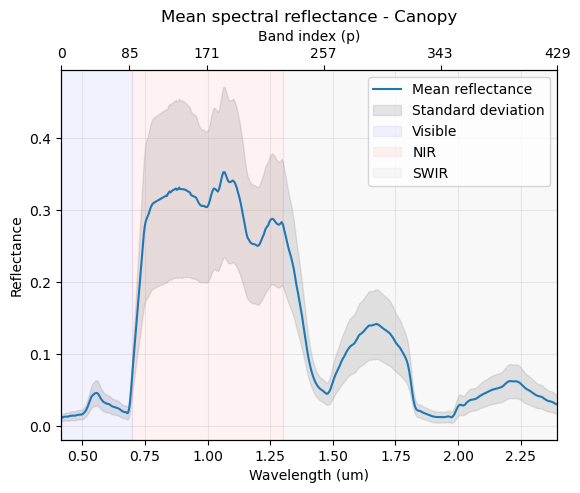

Computing grass stats: 100%|██████████| 27/27 [01:01<00:00,  2.27s/band-block]
grass: 5,017,474 pixels


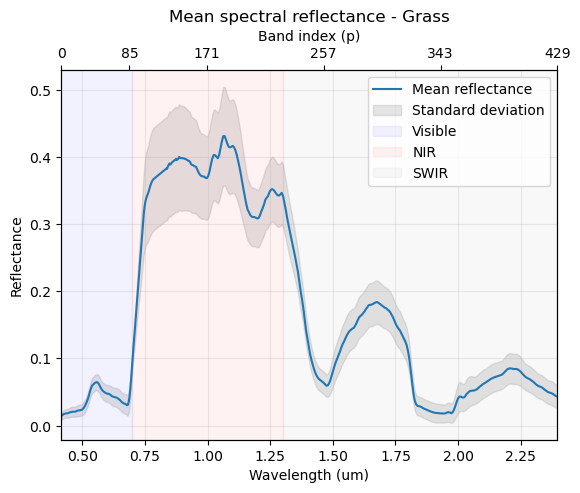

In [25]:
class_stats = {}
wavelengths = np.asarray(hs_zarr.attrs["wavelength"], dtype=np.float32)

for class_name, class_id, _ in class_mask_colors:
    mask = label_mask == class_id

    if mask.shape != hs_zarr.shape[:2]:
        raise ValueError(
            f"Mask shape {mask.shape} does not match image shape {hs_zarr.shape[:2]}"
        )

    bands = hs_zarr.shape[2]
    band_block = hs_zarr.chunks[2]

    mean = np.zeros(bands, dtype=np.float32)
    std = np.zeros(bands, dtype=np.float32)

    for b0 in tqdm(
        range(0, bands, band_block),
        desc=f"Computing {class_name} stats",
        unit="band-block",
        file=sys.stdout
    ):
        b1 = min(b0 + band_block, bands)

        block = hs_zarr[:, :, b0:b1]
        masked_block = block[mask, :]

        mean[b0:b1] = masked_block.mean(axis=0)
        std[b0:b1] = masked_block.std(axis=0)

    class_stats[class_name] = {
        "id": class_id,
        "pixels": int(mask.sum()),
        "mean": mean,
        "std": std,
    }

    print(f"{class_name}: {mask.sum():,} pixels")

    fig, ax = plt.subplots()
    ax.plot(wavelengths, mean, label="Mean reflectance")
    ax.fill_between(
        wavelengths,
        mean - std,
        mean + std,
        color="gray",
        alpha=0.2,
        label="Standard deviation",
    )

    ax.axvspan(0.4, 0.7, color="blue", alpha=0.05, label="Visible")
    ax.axvspan(0.7, 1.3, color="red", alpha=0.05, label="NIR")
    ax.axvspan(1.3, 2.5, color="gray", alpha=0.05, label="SWIR")

    ax.set_xlim(float(wavelengths.min()), float(wavelengths.max()))
    ax.set_title(f"Mean spectral reflectance - {class_name.title()}")
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Reflectance")
    ax.grid(True, alpha=0.25)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())

    tick_idx = np.linspace(0, len(wavelengths) - 1, 6, dtype=int)
    ax2.set_xticks([wavelengths[i] for i in tick_idx])
    ax2.set_xticklabels(tick_idx)
    ax2.set_xlabel("Band index (p)")

    ax.legend()
    plt.show()

## Review Summary Outputs

Build compact spectral summary tables for inspection only. These are intentionally not saved because they are small diagnostics and can be recomputed quickly.


In [26]:
stats_df = pd.DataFrame({"band": np.arange(len(wavelengths)), "wavelength": wavelengths})
for class_name, _, _ in class_mask_colors:
    stats_df[f"{class_name}_mean"] = class_stats[class_name]["mean"]
    stats_df[f"{class_name}_std"] = class_stats[class_name]["std"]

class_pixel_counts = pd.DataFrame(
    [
        {"class": class_name, "class_id": class_id, "pixels": class_stats[class_name]["pixels"]}
        for class_name, class_id, _ in class_mask_colors
    ]
)

display(class_pixel_counts)
display(stats_df.head())


,class,class_id,pixels
0,water,1,1889413
1,soil,2,1578685
2,canopy,3,2598161
3,grass,4,5017474


,band,wavelength,water_mean,water_std,soil_mean,soil_std,canopy_mean,canopy_std,grass_mean,grass_std
0,0,0.41618,0.016011,0.005131,0.054657,0.012789,0.011633,0.004738,0.014359,0.005419
1,1,0.41937,0.016618,0.005240,0.056824,0.013144,0.012216,0.004893,0.015284,0.005615
2,2,0.42257,0.017072,0.005318,0.059016,0.013487,0.012744,0.005045,0.016190,0.005810
3,3,0.42576,0.017506,0.005432,0.061430,0.013825,0.013271,0.005209,0.017081,0.006031
4,4,0.42896,0.017564,0.005462,0.062834,0.013958,0.013440,0.005297,0.017523,0.006172
